In [194]:
import pathlib
import jupedsim as jps
import pedpy
from numpy.random import normal  # normal distribution of free movement speed
from shapely import Polygon, GeometryCollection
import random

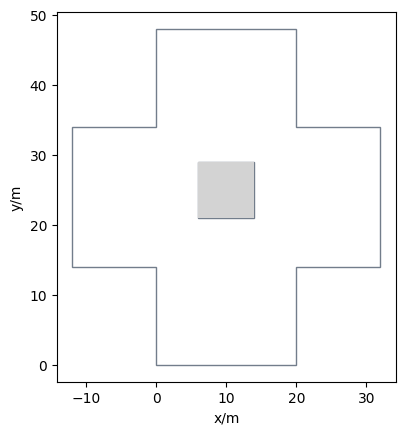

In [195]:
wings_length = 14
base_length = 20

# walkable areas
north_landing = Polygon([(0, wings_length+base_length), (20, wings_length+base_length), (20, wings_length*2+base_length), (0, wings_length*2+base_length)])
main_landing = Polygon([(-12, wings_length), (32, wings_length), (32, wings_length+base_length), (-12, wings_length+base_length)])
south_landing = Polygon([(0, 0), (20, 0), (20, wings_length), (0, wings_length)])

# obstacles
center_booth = Polygon([(6, 21), (14, 21), (14, 29), (6, 29)])

# switches
switch_n = (10, 34)
switch_s = (10, 14)

# waypoints
waypoints_n = [
    (4, 32),
    (16, 32)
]
waypoints_s = [
    (4, 16),
    (16, 16)
]

area = GeometryCollection(north_landing.union(main_landing).union(south_landing).difference(center_booth))
walkable_area = pedpy.WalkableArea(area)
pedpy.plot_walkable_area(walkable_area=walkable_area).set_aspect("equal")

In [ ]:
north_spawn_pos = []
south_spawn_pos = []
num_agents = 10

def spawn_in_area(area : Polygon, target_list : list):
    target_list.extend(
        jps.distributions.distribute_by_number(
            polygon=area,
            number_of_agents=num_agents,
            distance_to_agents=1.5,
            distance_to_polygon=0.2,
            seed=None,
        )
    )

# entrances
south_left_entrance = Polygon([(0, 0), (3, 0), (3, 10), (0, 10)])
south_right_entrance = Polygon([(17, 0), (20, 0), (20, 10), (17, 10)])
north_left_entrance = Polygon([(0, 38), (3, 38), (3, 48), (0, 48)])
north_right_entrance = Polygon([(17, 38), (20, 38), (20, 48), (17, 48)])

spawn_in_area(south_left_entrance, south_spawn_pos)
spawn_in_area(south_right_entrance, south_spawn_pos)
spawn_in_area(north_left_entrance, north_spawn_pos)
spawn_in_area(north_right_entrance, north_spawn_pos)

# exits
right_exit = Polygon([(30, 14), (32, 14), (32, 34), (30, 34)])
left_exit = Polygon([(-12, 14), (-10, 14), (-10, 34), (-12, 34)])
exit_areas = [right_exit, left_exit]

In [197]:
def plot_simulation_configuration(
    walkable_area, spawning_area, starting_positions, exit_area
):
    axes = pedpy.plot_walkable_area(walkable_area=walkable_area)
    axes.fill(*spawning_area.exterior.xy, color="lightgrey")
    axes.fill(*exit_area.exterior.xy, color="indianred")
    axes.scatter(*zip(*starting_positions))
    axes.set_xlabel("x/m")
    axes.set_ylabel("y/m")
    axes.set_aspect("equal")

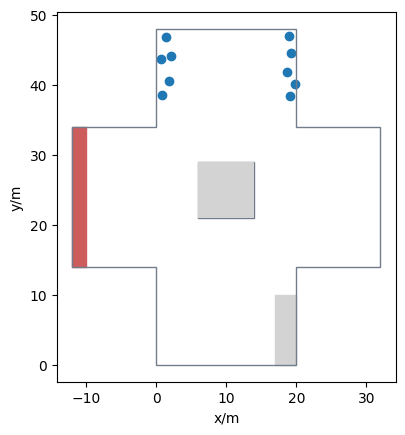

In [198]:
plot_simulation_configuration(
    walkable_area, south_right_entrance, north_spawn_pos, left_exit
)

In [199]:
trajectory_file = "corner.sqlite"  # output file
simulation = jps.Simulation(
    model=jps.AnticipationVelocityModel(),
    geometry=area,
    trajectory_writer=jps.SqliteTrajectoryWriter(
        output_file=pathlib.Path(trajectory_file)
    ),
)

In [200]:
def least_targeted(
    simulation: jps.Simulation, switch_id, waypoint_ids, exit_id
):
    """Build a journey with least targeted transitions for a given simulation."""

    journey = jps.JourneyDescription([switch_id, *waypoint_ids, exit_id])
    # switch ---> least targeted waypoint
    journey.set_transition_for_stage(
        switch_id,
        jps.Transition.create_least_targeted_transition(waypoint_ids),
    )
    # from all waypoints ---> exit
    for waypoint_id in waypoint_ids:
        journey.set_transition_for_stage(
            waypoint_id, jps.Transition.create_fixed_transition(exit_id)
        )

    journey_id = simulation.add_journey(journey)
    return journey_id

In [201]:
exit_ids = []
for exit_area in exit_areas:
    exit_ids.append(simulation.add_exit_stage(exit_area.exterior.coords[:-1]))

left_exit_id = exit_ids[0]
right_exit_id = exit_ids[1]
    
south_switch_id = simulation.add_waypoint_stage(switch_s, 1)
north_switch_id = simulation.add_waypoint_stage(switch_n, 1)

south_waypoint_ids = [ 
    simulation.add_waypoint_stage(waypoint, 1)
    for waypoint in waypoints_s
]

north_waypoint_ids = [ 
    simulation.add_waypoint_stage(waypoint, 1)
    for waypoint in waypoints_n
]

# SOUTH JOURNEYS (one to left, one to right)
south_journey_toleft_id = least_targeted(simulation, south_switch_id, south_waypoint_ids, left_exit_id)
south_journey_toright_id = least_targeted(simulation, south_switch_id, south_waypoint_ids, right_exit_id)

# NORTH JOURNEYS
north_journey_toleft_id = least_targeted(simulation, north_switch_id, north_waypoint_ids, left_exit_id)
north_journey_toright_id = least_targeted(simulation, north_switch_id, north_waypoint_ids, right_exit_id)


In [ ]:
south_index = 0
north_index = 0

south_speeds = normal(1.34, 0.05, len(south_spawn_pos))
north_speeds = normal(1.34, 0.05, len(north_spawn_pos))

max_frames = 10000
frame = 0

spawn_interval = 400

while frame < max_frames:

    if frame % spawn_interval == 0:

        # SOUTH SPAWN
        if south_index < len(south_spawn_pos):
            pos = south_spawn_pos[south_index]
            v0 = south_speeds[south_index]

            simulation.add_agent(
                jps.AnticipationVelocityModelAgentParameters(
                    journey_id=random.choice([south_journey_toleft_id, south_journey_toright_id]),
                    stage_id=south_switch_id,
                    position=pos,
                    desired_speed=v0,
                )
            )

            south_index += 1

        # NORTH SPAWN
        if north_index < len(north_spawn_pos):
            pos = north_spawn_pos[north_index]
            v0 = north_speeds[north_index]

            simulation.add_agent(
                jps.AnticipationVelocityModelAgentParameters(
                    journey_id=random.choice([north_journey_toleft_id, north_journey_toright_id]),
                    stage_id=north_switch_id,
                    position=pos,
                    desired_speed=v0,
                )
            )

            north_index += 1

    simulation.iterate()
    frame += 1

    # Optional: break early if everything done
    if (
        south_index >= len(south_spawn_pos)
        and north_index >= len(north_spawn_pos)
        and simulation.agent_count() == 0
    ):
        break


In [203]:
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)
animate(trajectory_data, walkable_area, every_nth_frame=10)